# pybalmorel for Post-Processing
This notebook provide examples on how to use pybalmorel for pre-processing, post-processing and for executing Balmorel scenarios. Check the following pages:
- [Home](../README.md)
- [Pre-Processing](PreProcessing.ipynb)
- [Execution](Execution.ipynb)

In [55]:
import os
import pandas as pd
import sys

# Adjust the sys.path to include the project root directory
project_root = os.path.abspath(os.path.join(os.path.dirname("__file__"), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from src.pybalmorel import MainResults

gams_system_directory = "/Library/Frameworks/GAMS.framework/Versions/53/Resources"

In [101]:
### 1.1.2 Loading several scenarios
res = MainResults(files=['MainResults_base.gdx',
                         'MainResults_NZwoCCS.gdx',
                        'MainResults_NZwCCS.gdx',
                        'MainResults_NZwCCS2.gdx',
                        'MainResults_CO2TaxwCCS.gdx',
                        'MainResults_NNwCCS.gdx'],
                    paths=['Balmorel/01Project_base/Model',
                            'Balmorel/02Project_NZwithoutCCS/Model',
                            'Balmorel/03Project_NZwCCS/Model',
                            'Balmorel/03Project_NZwCCS2/Model',
                            'Balmorel/04Project_CO2TaxwCCS/Model',
                            'Balmorel/05Project_NNwCCS/Model'],
                    scenario_names=['Base Scenario', 'Net-Zero w/o CCS', 'Net-Zero w CCS','Net-Zero w CCS 2', 'CO2 Tax w CCS', 'Net-Negative w CCS'],
                    system_directory=gams_system_directory)


Loading Balmorel/01Project_base/Model/MainResults_base.gdx
Loading Balmorel/02Project_NZwithoutCCS/Model/MainResults_NZwoCCS.gdx
Loading Balmorel/03Project_NZwCCS/Model/MainResults_NZwCCS.gdx
Loading Balmorel/03Project_NZwCCS2/Model/MainResults_NZwCCS2.gdx
Loading Balmorel/04Project_CO2TaxwCCS/Model/MainResults_CO2TaxwCCS.gdx
Loading Balmorel/05Project_NNwCCS/Model/MainResults_NNwCCS.gdx


/Users/wiwillym/Desktop/Cote/LSESA/Project/pybalmorel/src/pybalmorel/classes.py:100: UserWarning: The GAMS version (53.5.1) differs from the API version (54.1.0).
  ws = gams.GamsWorkspace(system_directory=system_directory)


In [102]:
G_CAP_YCRAF = pd.DataFrame(res.get_result('G_CAP_YCRAF'))

In [107]:
PRO_YCRAGF = pd.DataFrame(res.get_result('PRO_YCRAGF'))

In [103]:
EMI_YCRAG = pd.DataFrame(res.get_result('EMI_YCRAG'))

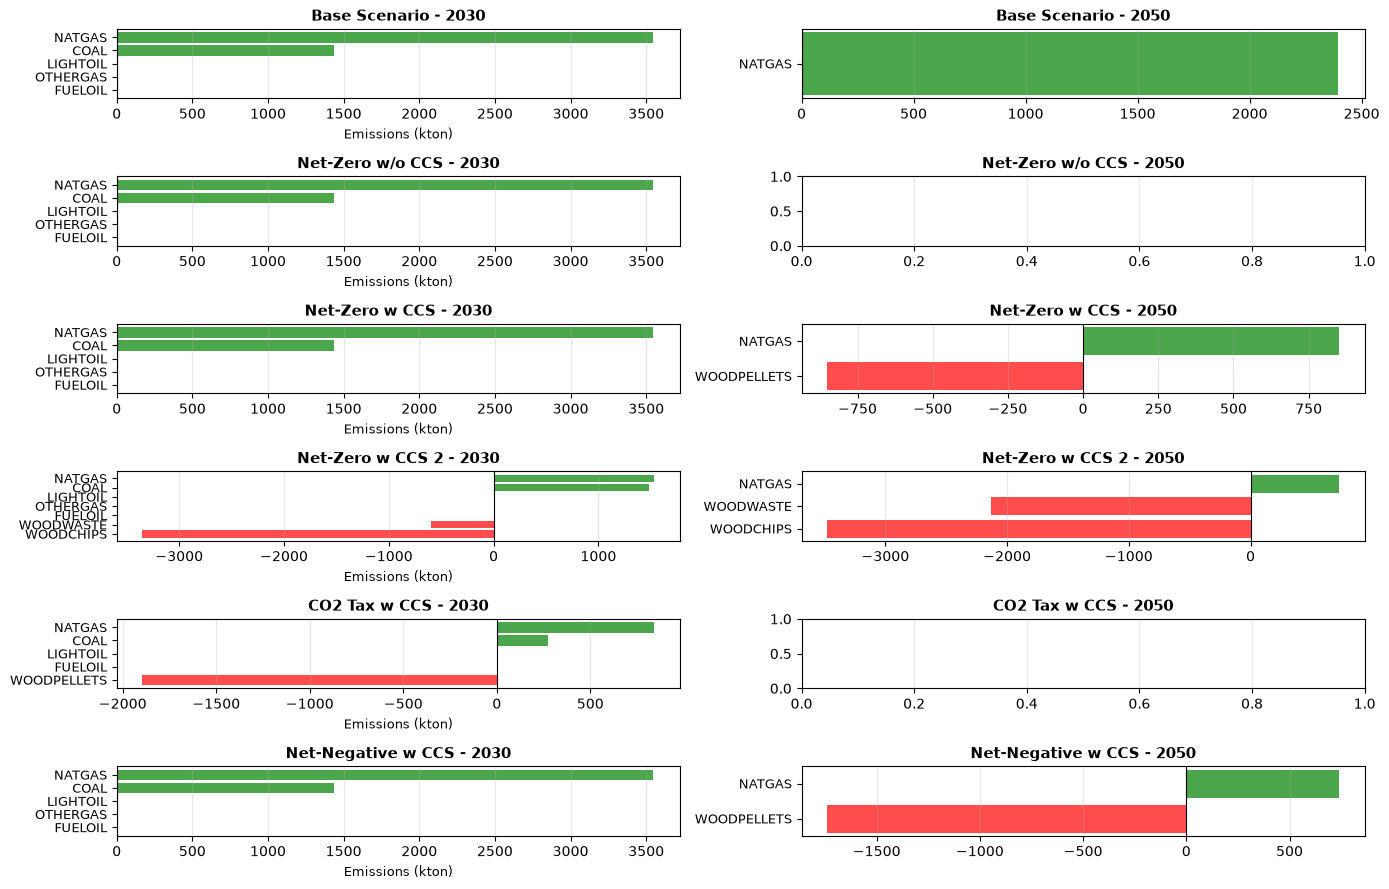

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def plot_emissions_grid_by_year_and_scenario(
    emissions_df: pd.DataFrame, years: list = None, scenarios: list = None
):
    """Plot emissions in a 2x2 grid (years as columns, scenarios as rows), grouped by fuel.

    Args:
        emissions_df (pd.DataFrame): Emissions results dataframe.
        years (list, optional): Years to plot. Defaults to all available.
        scenarios (list, optional): Scenarios to plot. Defaults to all available.

    Returns:
        tuple[plt.Figure, np.ndarray]: The figure and axes array.
    """
    # Get available years and scenarios
    if years is None:
        years = sorted(emissions_df["Y"].unique())
    else:
        years = [str(y) for y in years]  # Convert to strings to match data

    if scenarios is None:
        scenarios = sorted(emissions_df["Scenario"].unique())

    # Create 2x2 grid (rows=scenarios, columns=years)
    fig, axes = plt.subplots(len(scenarios), len(years), figsize=(14, 9))
    if len(scenarios) == 1 and len(years) == 1:
        axes = np.array([[axes]])
    elif len(scenarios) == 1:
        axes = axes.reshape(1, -1)
    elif len(years) == 1:
        axes = axes.reshape(-1, 1)

    # Plot each combination
    for i, scenario in enumerate(scenarios):
        for j, year in enumerate(years):
            ax = axes[i, j]

            # Filter data for this scenario and year
            filtered = emissions_df[
                (emissions_df["Scenario"] == scenario) & (emissions_df["Y"] == year)
            ]

            if not filtered.empty:
                # Group by fuel type and sum emissions
                fuel_emissions = filtered.groupby("FFF")["Value"].sum().sort_values()

                # Plot as horizontal bar chart for better readability
                colors = ["red" if v < 0 else "green" for v in fuel_emissions.values]
                ax.barh(
                    range(len(fuel_emissions)),
                    fuel_emissions.values,
                    color=colors,
                    alpha=0.7,
                )
                ax.set_yticks(range(len(fuel_emissions)))
                ax.set_yticklabels(fuel_emissions.index, fontsize=9)
                ax.axvline(0, color="black", linewidth=0.8)

            ax.set_title(f"{scenario} - {year}", fontsize=11, fontweight="bold")
            ax.set_xlabel("Emissions (kton)" if j == 0 else "", fontsize=9)
            ax.grid(True, axis="x", alpha=0.3)

    plt.tight_layout()
    return fig, axes


# Plot 2x2 grid: rows=scenarios, columns=years
scenarios = [
    "Base Scenario",
    "Net-Zero w/o CCS",
    "Net-Zero w CCS",
    "Net-Zero w CCS 2",
    "CO2 Tax w CCS",
    "Net-Negative w CCS",
]
years = [2030, 2050]
fig, axes = plot_emissions_grid_by_year_and_scenario(
    EMI_YCRAG, years=years, scenarios=scenarios
)

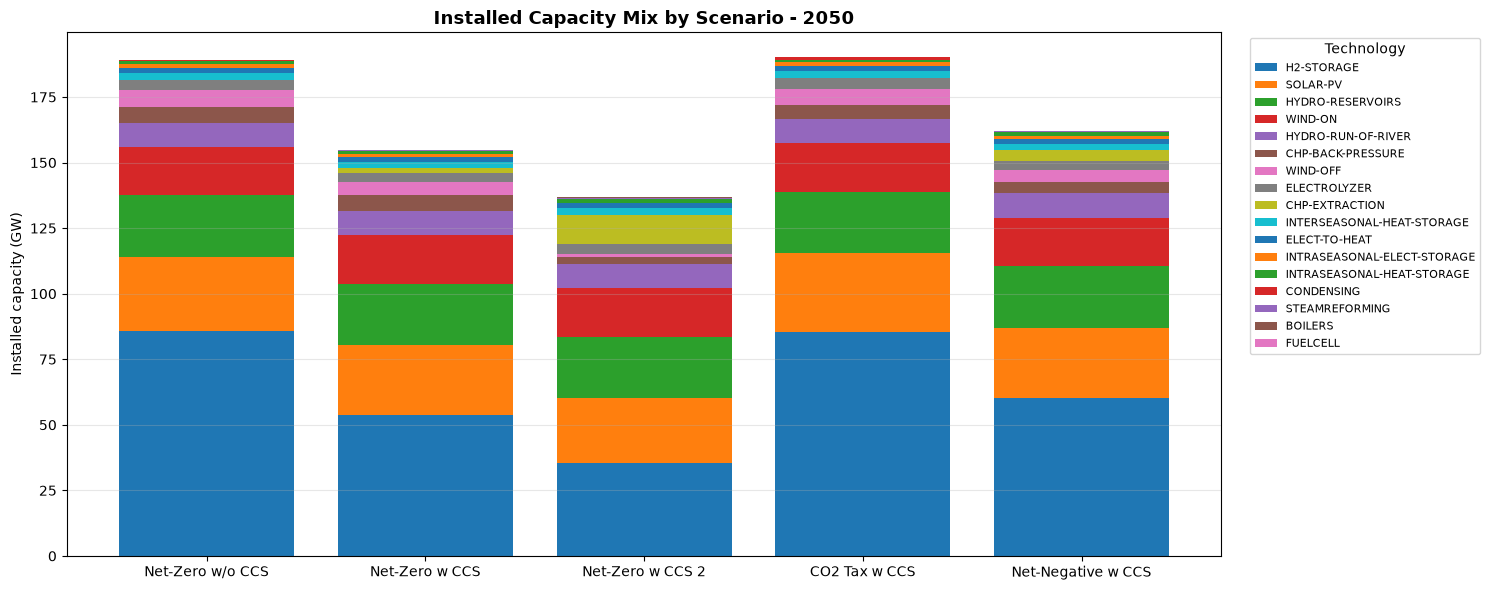

In [ ]:
def plot_capacity_stacked_bar_by_scenario(
    capacity_df: pd.DataFrame,
    year: int = None,
    scenarios: list = None,
    min_capacity: float = 0.0,
):
    """
    Plot installed capacity mix as one stacked bar chart:
    x-axis = scenarios, stacked bars = technologies.

    Args:
        capacity_df (pd.DataFrame): Installed capacity results dataframe.
        year (int, optional): Year to plot. If None, uses all years.
        scenarios (list, optional): Scenarios to plot. Defaults to all available.
        min_capacity (float, optional): Minimum total technology capacity to show.
            Technologies below this total are grouped as 'Other'.

    Returns:
        tuple[plt.Figure, plt.Axes]: The figure and axis.
    """

    df = capacity_df.copy()

    df["Scenario_clean"] = df["Scenario"].astype(str).str.strip()
    df["Scenario_key"] = df["Scenario_clean"].str.lower()
    df["Year"] = df["Year"].astype(int)

    if year is not None:
        year = int(year)
        df = df[df["Year"] == year]

    if scenarios is None:
        scenarios = sorted(df["Scenario_clean"].unique())
    else:
        scenario_keys = [str(s).strip().lower() for s in scenarios]
        df = df[df["Scenario_key"].isin(scenario_keys)]

        # Preserve the order provided by the user
        scenario_order = {
            str(s).strip().lower(): str(s).strip()
            for s in scenarios
        }
        df["Scenario_clean"] = df["Scenario_key"].map(scenario_order)

    # Aggregate capacity by scenario and technology
    plot_df = (
        df.groupby(["Scenario_clean", "Technology"])["Value"]
        .sum()
        .reset_index()
    )

    # Remove zero or negative capacities
    plot_df = plot_df[plot_df["Value"] > 0]

    # Pivot to get scenarios as rows and technologies as columns
    pivot_df = (
        plot_df.pivot_table(
            index="Scenario_clean",
            columns="Technology",
            values="Value",
            aggfunc="sum",
            fill_value=0,
        )
    )

    # Preserve scenario order
    if scenarios is not None:
        pivot_df = pivot_df.reindex([str(s).strip() for s in scenarios])

    # Group very small technologies into "Other"
    technology_totals = pivot_df.sum(axis=0)
    small_techs = technology_totals[technology_totals < min_capacity].index

    if len(small_techs) > 0:
        pivot_df["Other"] = pivot_df[small_techs].sum(axis=1)
        pivot_df = pivot_df.drop(columns=small_techs)

    # Sort technologies by total installed capacity, largest first
    pivot_df = pivot_df[pivot_df.sum(axis=0).sort_values(ascending=False).index]

    fig, ax = plt.subplots(figsize=(15, 6))

    bottom = np.zeros(len(pivot_df))

    for technology in pivot_df.columns:
        ax.bar(
            pivot_df.index,
            pivot_df[technology].values,
            bottom=bottom,
            label=technology,
        )
        bottom += pivot_df[technology].values

    title = "Installed Capacity Mix by Scenario"
    if year is not None:
        title += f" - {year}"

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylabel("Installed capacity (GW)")
    ax.grid(True, axis="y", alpha=0.3)

    ax.legend(
        title="Technology",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=8,
    )

    plt.tight_layout()

    return fig, ax
# Plot 2x2 grid: rows=scenarios, columns=years
scenarios = [
    "Net-Zero w/o CCS",
    "Net-Zero w CCS",
    "Net-Zero w CCS 2",
    "CO2 Tax w CCS",
    "Net-Negative w CCS",
]

fig, ax = plot_capacity_stacked_bar_by_scenario(
    G_CAP_YCRAF,
    year=2050,
    scenarios=scenarios,
    min_capacity=0.0,
)

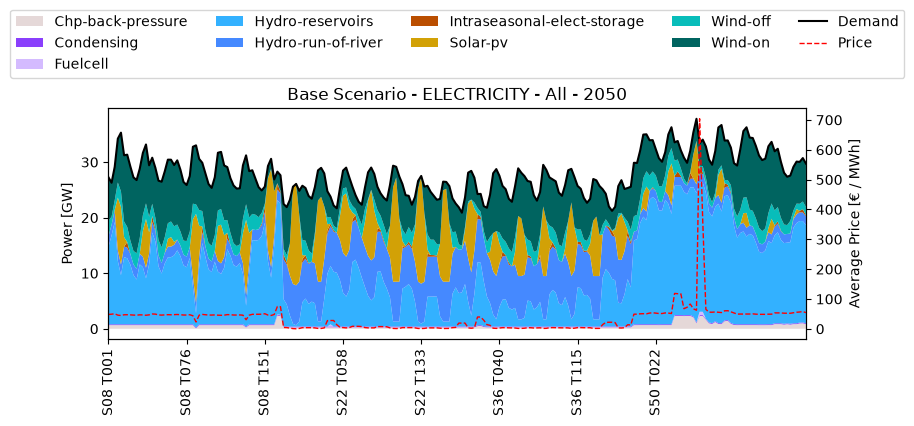

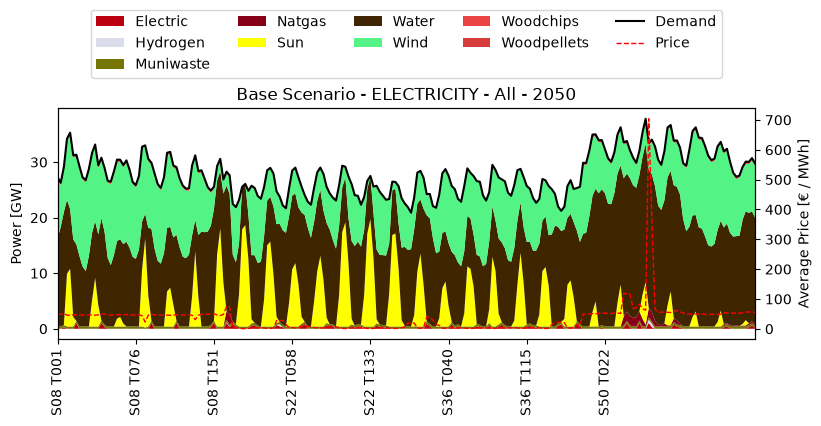

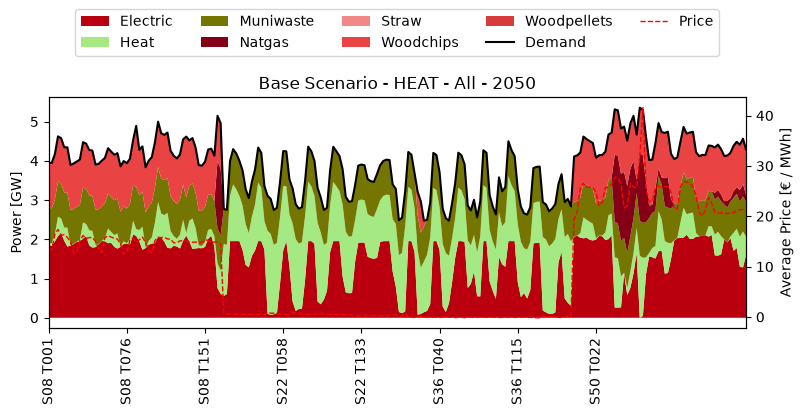

In [77]:
fig, ax = res.plot_profile(scenario='Base Scenario', year=2050, commodity='Electricity', columns='Technology')
fig, ax = res.plot_profile(scenario='Base Scenario', year=2050, commodity='Electricity', columns='Fuel')
fig, ax = res.plot_profile(scenario='Base Scenario', year=2050, commodity='Heat', columns='Fuel')

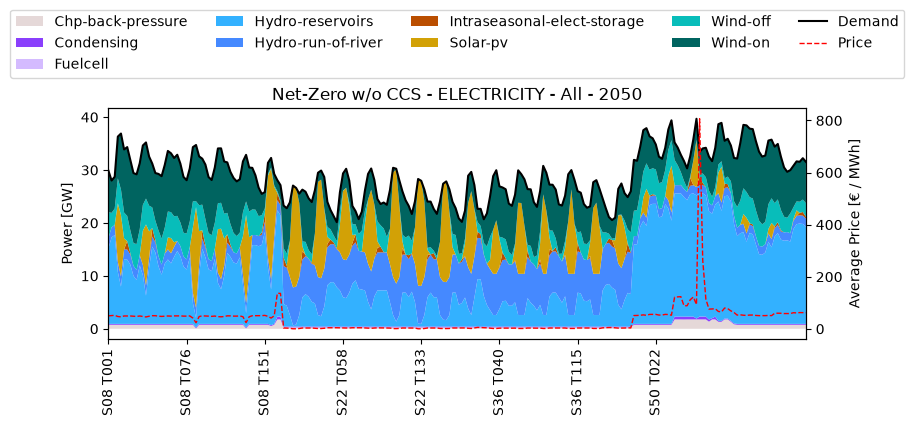

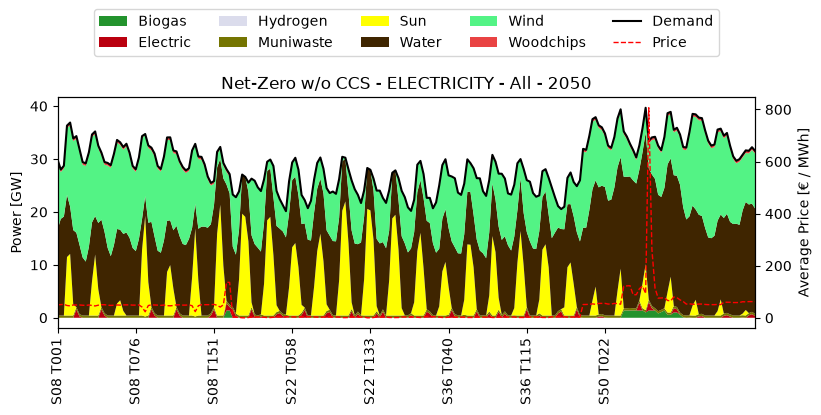

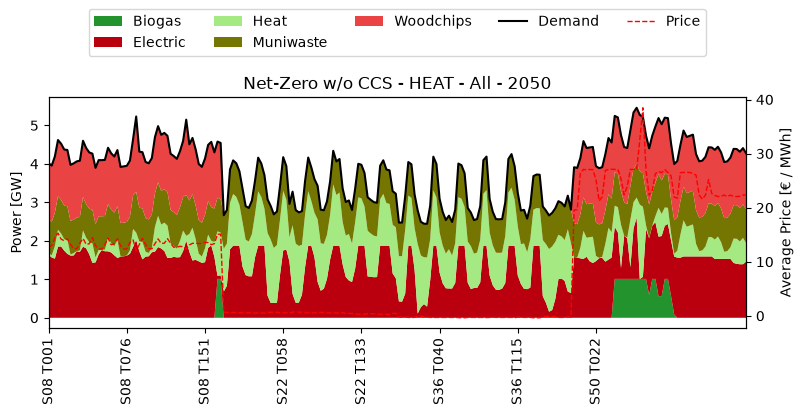

In [78]:
fig, ax = res.plot_profile(scenario='Net-Zero w/o CCS', year=2050, commodity='Electricity', columns='Technology')
fig, ax = res.plot_profile(scenario='Net-Zero w/o CCS', year=2050, commodity='Electricity', columns='Fuel')
fig, ax = res.plot_profile(scenario='Net-Zero w/o CCS', year=2050, commodity='Heat', columns='Fuel')

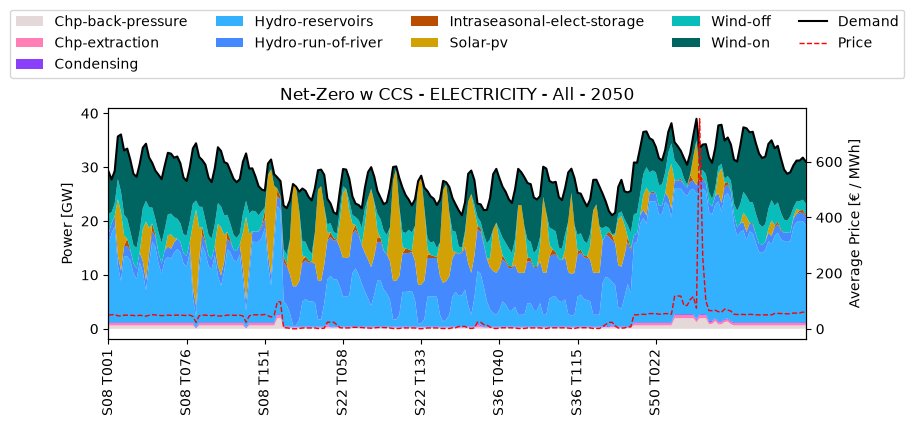

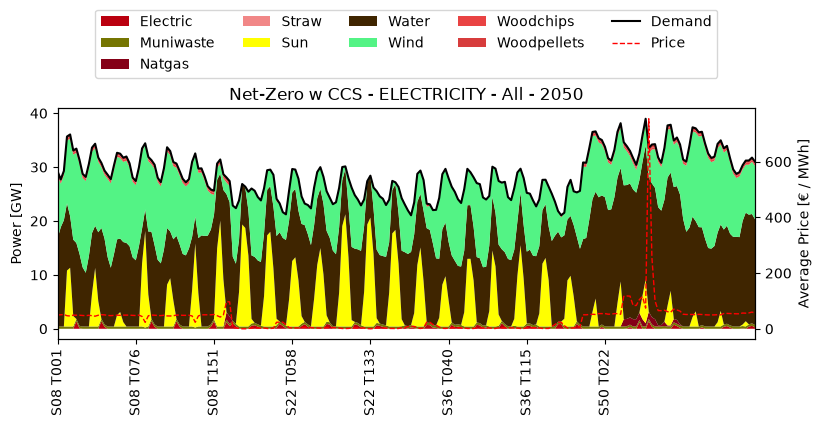

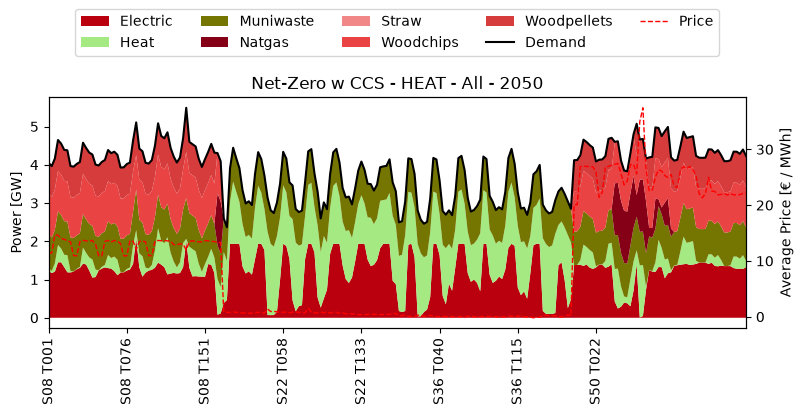

In [85]:
fig, ax = res.plot_profile(scenario='Net-Zero w CCS', year=2050, commodity='Electricity', columns='Technology')
fig, ax = res.plot_profile(scenario='Net-Zero w CCS', year=2050, commodity='Electricity', columns='Fuel')
fig, ax = res.plot_profile(scenario='Net-Zero w CCS', year=2050, commodity='Heat', columns='Fuel')

No defined colour for WOODWASTE
No defined colour for WOODWASTE


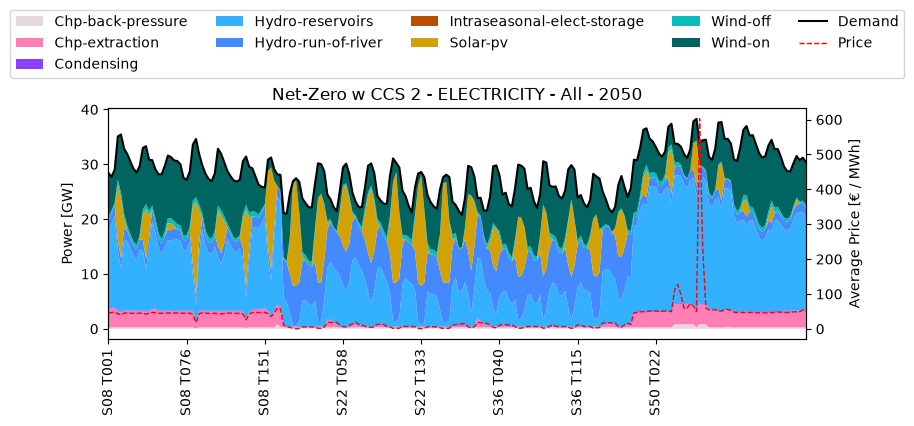

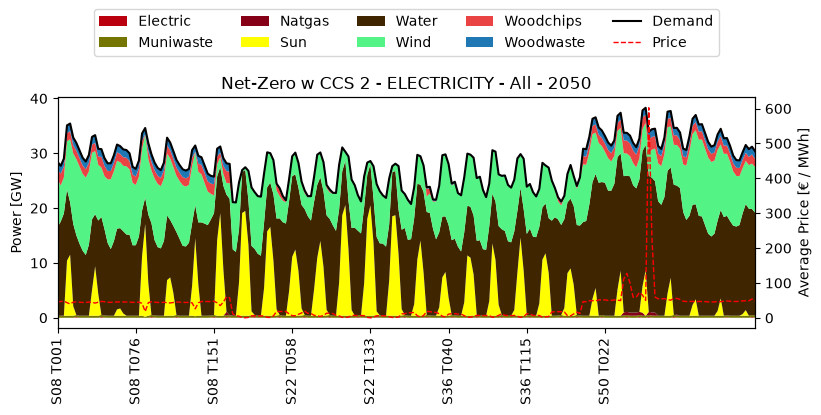

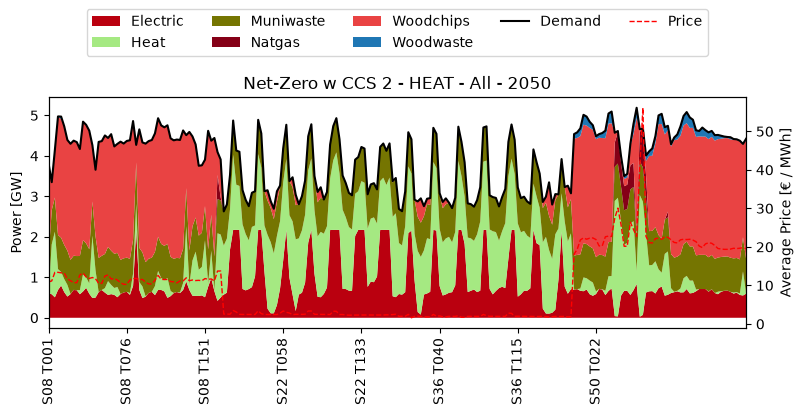

In [105]:
fig, ax = res.plot_profile(scenario='Net-Zero w CCS 2', year=2050, commodity='Electricity', columns='Technology')
fig, ax = res.plot_profile(scenario='Net-Zero w CCS 2', year=2050, commodity='Electricity', columns='Fuel')
fig, ax = res.plot_profile(scenario='Net-Zero w CCS 2', year=2050, commodity='Heat', columns='Fuel')

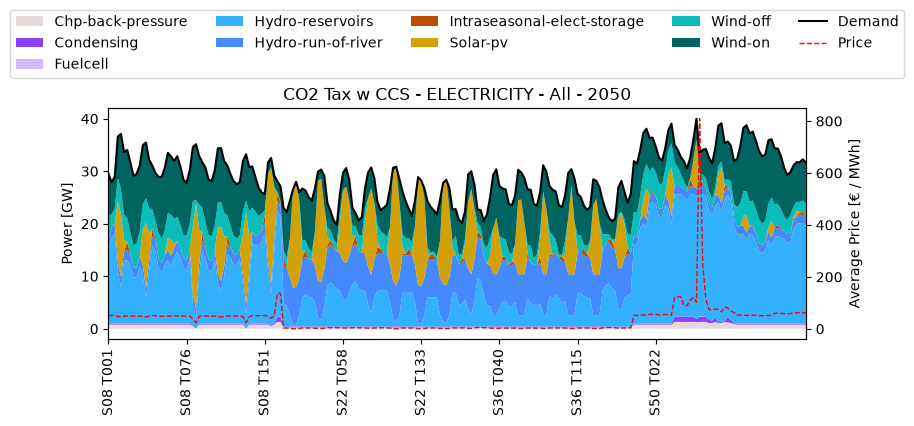

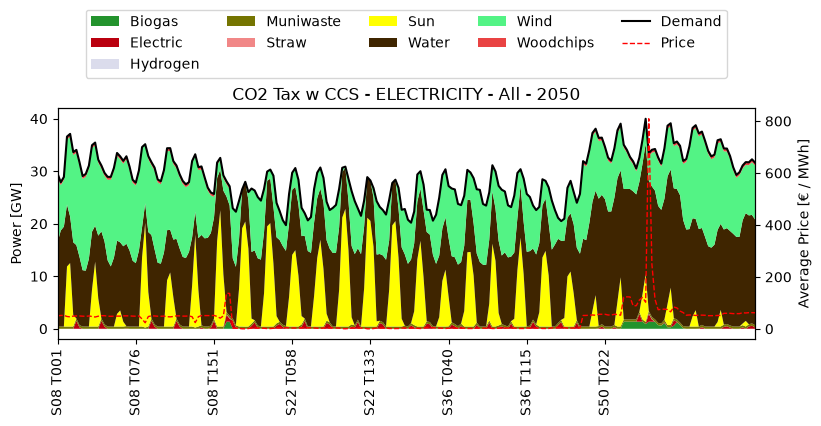

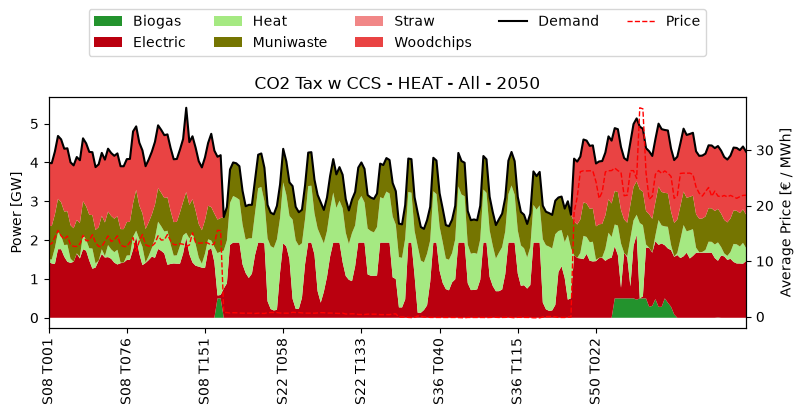

In [90]:
fig, ax = res.plot_profile(scenario='CO2 Tax w CCS', year=2050, commodity='Electricity', columns='Technology')
fig, ax = res.plot_profile(scenario='CO2 Tax w CCS', year=2050, commodity='Electricity', columns='Fuel')
fig, ax = res.plot_profile(scenario='CO2 Tax w CCS', year=2050, commodity='Heat', columns='Fuel')

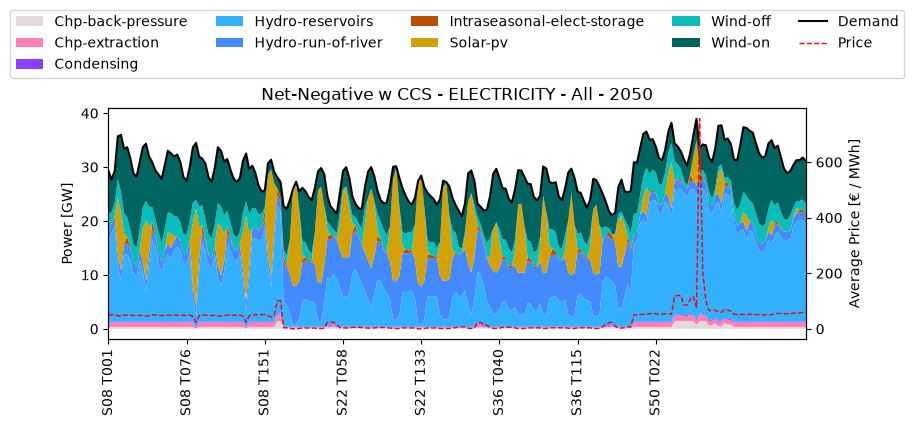

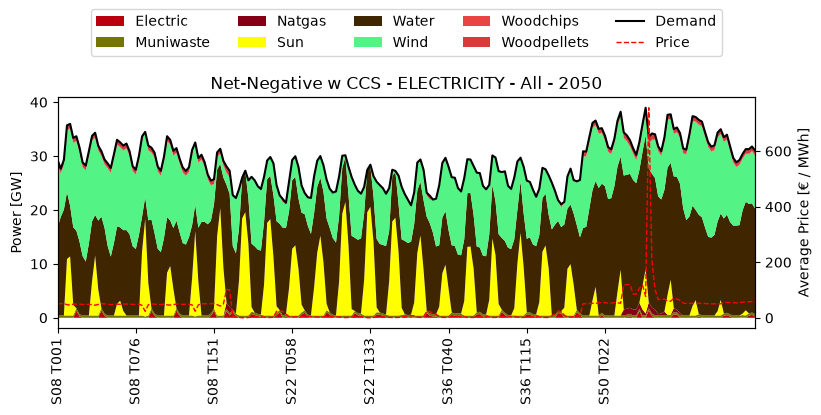

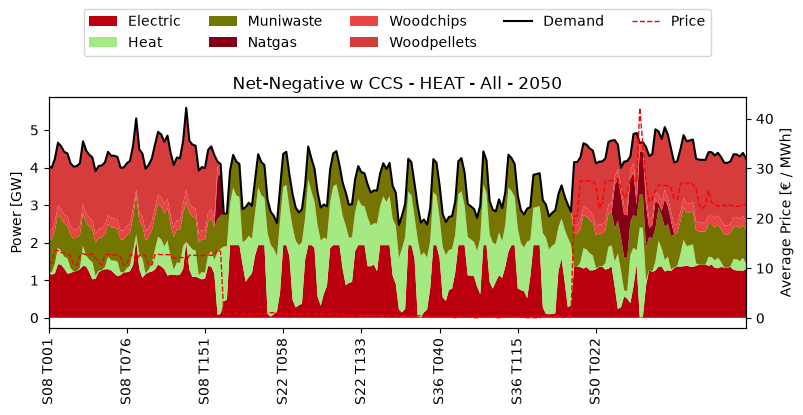

In [100]:
fig, ax = res.plot_profile(scenario='Net-Negative w CCS', year=2050, commodity='Electricity', columns='Technology')
fig, ax = res.plot_profile(scenario='Net-Negative w CCS', year=2050, commodity='Electricity', columns='Fuel')
fig, ax = res.plot_profile(scenario='Net-Negative w CCS', year=2050, commodity='Heat', columns='Fuel')

In [ ]:
res.plot